# Capstone: Classifying Iris species

**Question:** Can four flower measurements distinguish three Iris species?

This notebook validates the data, immediately locks a test set, explores training data only, compares leakage-safe pipelines, interprets the selected approach on a training-derived validation subset, and reports one final test result.

**Primary metric:** macro-F1, which gives each species equal weight.

**Reproducibility:** all randomized steps use explicit seeds. Run the notebook from top to bottom.

## 1. Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.datasets import load_iris
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
INTERPRETATION_RANDOM_STATE = 43
BOOTSTRAP_RANDOM_STATE = 2026
TEST_SIZE = 0.20
VALIDATION_SIZE = 0.20
PRIMARY_METRIC = "macro-F1"
PRIMARY_SCORING = "f1_macro"
TIE_TOLERANCE = 1e-6
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")

print("Split seed:", RANDOM_STATE)
print("Primary metric:", PRIMARY_METRIC)

Split seed: 42
Primary metric: macro-F1


## 2. Load, validate, and immediately lock the test set

Scikit-learn bundles this small dataset. Only contract checks touch the complete data. A stratified test set is then locked away before any target counts, relationships, or plots are produced.

In [2]:
EXPECTED_FEATURES = [
    "sepal length (cm)", "sepal width (cm)",
    "petal length (cm)", "petal width (cm)",
]
iris = load_iris(as_frame=True)
EXPECTED_CLASS_COUNTS = {"setosa": 50, "versicolor": 50, "virginica": 50}
X = iris.data.copy()
y = iris.target.map(dict(enumerate(iris.target_names))).rename("species")
df = X.assign(species=y)

if df.shape != (150, 5):
    raise ValueError(f"Expected Iris shape (150, 5), received {df.shape}.")
if X.columns.tolist() != EXPECTED_FEATURES:
    raise ValueError(f"Unexpected Iris feature schema: {X.columns.tolist()}")
for column in EXPECTED_FEATURES:
    if not pd.api.types.is_numeric_dtype(X[column]):
        raise ValueError(f"{column} must have a numeric dtype.")
if not np.isfinite(X.to_numpy(dtype=float)).all():
    raise ValueError("Iris predictors must contain only finite numeric values.")
if df.isna().any().any():
    raise ValueError("Iris unexpectedly contains missing values.")
if y.isna().any() or set(y.unique()) != set(iris.target_names):
    raise ValueError("Unexpected Iris target labels.")
if y.value_counts().to_dict() != EXPECTED_CLASS_COUNTS:
    raise ValueError(f"Unexpected Iris target counts: {y.value_counts().to_dict()}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)
X_fit, X_validation, y_fit, y_validation = train_test_split(
    X_train, y_train, test_size=VALIDATION_SIZE,
    stratify=y_train, random_state=INTERPRETATION_RANDOM_STATE,
)
train_df = X_fit.assign(species=y_fit)

if not X_train.index.intersection(X_test.index).empty:
    raise ValueError("Train/test indices overlap.")
if not X_fit.index.intersection(X_validation.index).empty:
    raise ValueError("Fit/validation indices overlap.")

print(f"Validated source: {len(df)} rows, {X.shape[1]} predictors, {y.nunique()} classes")
print(f"Locked split: {len(X_train)} training rows, {len(X_test)} test rows")
print(f"Development split: {len(X_fit)} fit rows, {len(X_validation)} validation rows")
print("EDA and CV use only fit rows; validation is reserved for interpretation.")
train_df.head()

Validated source: 150 rows, 4 predictors, 3 classes
Locked split: 120 training rows, 30 test rows
Development split: 96 fit rows, 24 validation rows
EDA and CV use only fit rows; validation is reserved for interpretation.


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
32,5.2,4.1,1.5,0.1,setosa
120,6.9,3.2,5.7,2.3,virginica
124,6.7,3.3,5.7,2.1,virginica
126,6.2,2.8,4.8,1.8,virginica
71,6.1,2.8,4.0,1.3,versicolor


In [3]:
overview = pd.DataFrame({
    "dtype": train_df.dtypes.astype(str),
    "missing": train_df.isna().sum(),
    "unique": train_df.nunique(),
})
print("Exact duplicate fit rows:", train_df.duplicated().sum())
print("\nFit-partition class counts:")
print(y_fit.value_counts().sort_index())
overview

Exact duplicate fit rows: 0

Fit-partition class counts:
species
setosa        32
versicolor    32
virginica     32
Name: count, dtype: int64


,dtype,missing,unique
sepal length (cm),float64,0,30
sepal width (cm),float64,0,22
petal length (cm),float64,0,37
petal width (cm),float64,0,21
species,object,0,3


The fit-partition target is balanced by construction through stratification. No value is missing. A few exact duplicates can occur because measurements were rounded; they are retained as valid observations in this teaching dataset.

## 3. Exploratory data analysis — fit partition only

All target counts and relationships below use `train_df`, which contains only `X_fit/y_fit`. Validation and test remain hidden. EDA suggests hypotheses; it does not estimate final predictive performance.

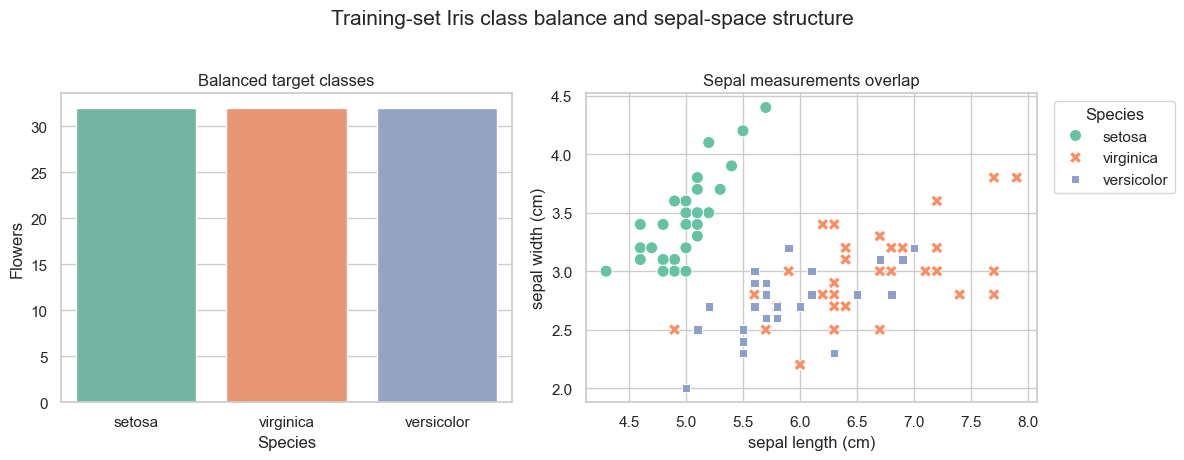

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.countplot(data=train_df, x="species", hue="species", palette="Set2", legend=False, ax=axes[0])
axes[0].set(title="Balanced target classes", xlabel="Species", ylabel="Flowers")

sns.scatterplot(
    data=train_df,
    x="sepal length (cm)",
    y="sepal width (cm)",
    hue="species",
    style="species",
    s=75,
    palette="Set2",
    ax=axes[1],
)
axes[1].set_title("Sepal measurements overlap")
axes[1].legend(title="Species", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.suptitle("Training-set Iris class balance and sepal-space structure", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

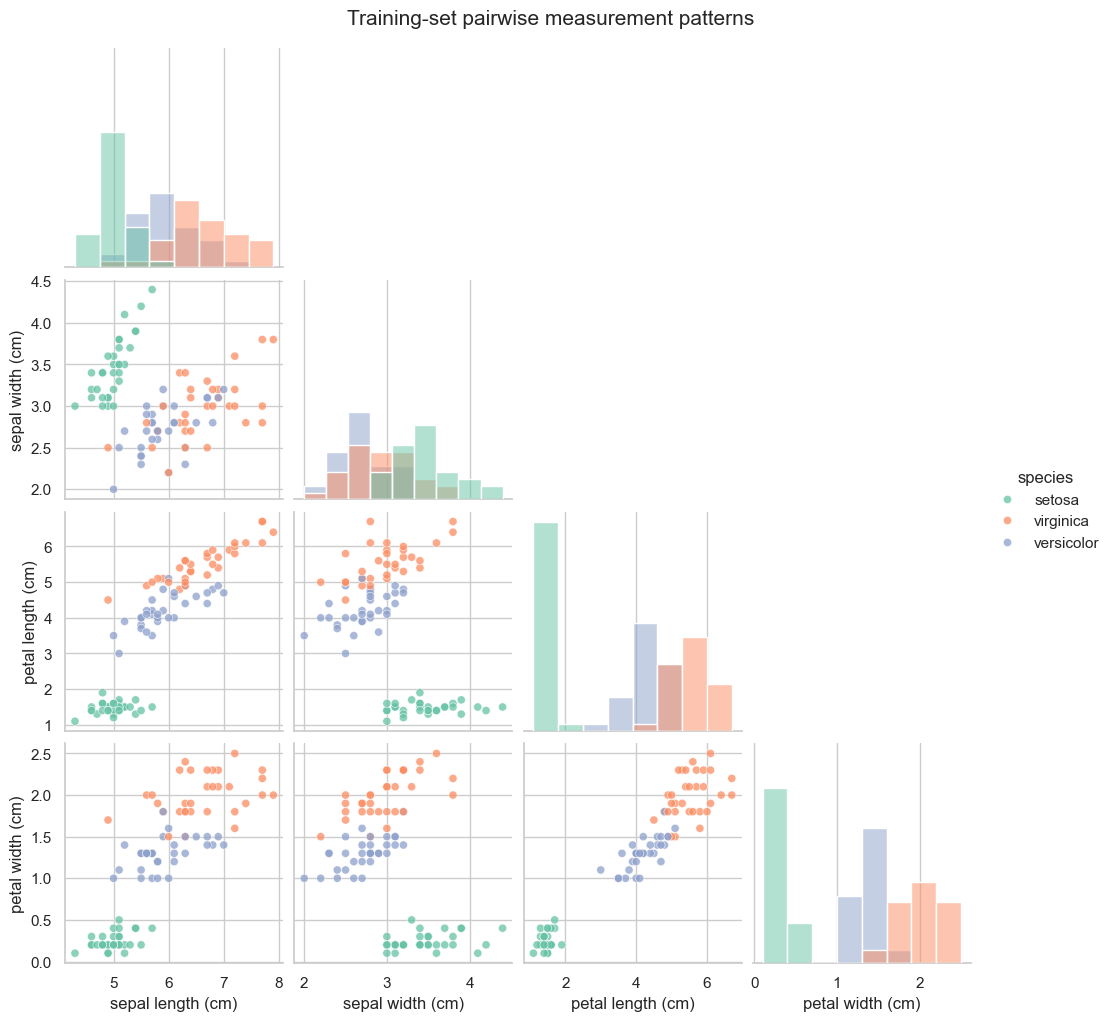

In [5]:
pair_grid = sns.pairplot(
    train_df,
    hue="species",
    corner=True,
    diag_kind="hist",
    palette="Set2",
    plot_kws={"alpha": 0.75, "s": 35},
)
pair_grid.fig.suptitle("Training-set pairwise measurement patterns", y=1.02, fontsize=15)
plt.show()

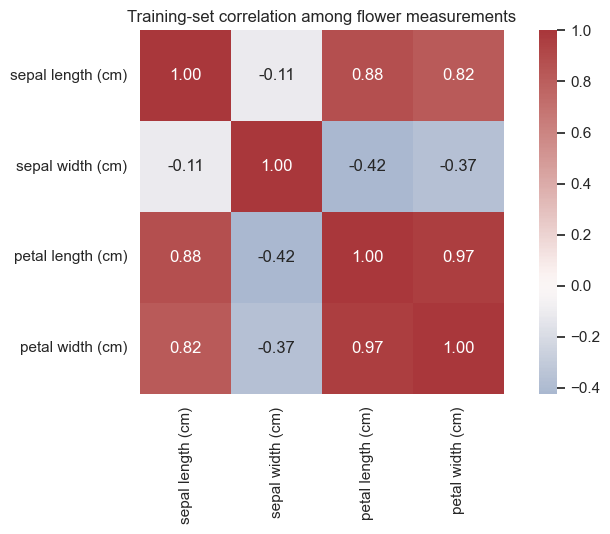

In [6]:
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.heatmap(
    X_fit.corr(),
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    square=True,
    ax=ax,
)
ax.set_title("Training-set correlation among flower measurements")
plt.tight_layout()
plt.show()

In [7]:
train_df.groupby("species", observed=True)[X.columns].agg(["mean", "std"]).round(2)

sepal length (cm)       sepal width (cm)       petal length (cm)  \
                        mean   std             mean   std              mean   
species                                                                       
setosa                  5.00  0.29             3.47  0.37              1.47   
versicolor              5.92  0.51             2.72  0.30              4.22   
virginica               6.61  0.69             2.98  0.37              5.53   

                 petal width (cm)        
             std             mean   std  
species                                  
setosa      0.15             0.24  0.10  
versicolor  0.49             1.30  0.19  
virginica   0.55             1.99  0.26

Petal measurements appear to separate species more clearly than sepal measurements in the fit partition. Later permutation importance checks this hypothesis on the separate validation subset—not on the locked test set.

## 4. Select a leakage-safe pipeline with training data only

`StandardScaler` sits inside each pipeline, so every cross-validation fold learns scaling only from its own training subset. Five-fold stratified cross-validation selects by the declared primary metric, macro-F1; accuracy is secondary.

**Explicit tie rule:** models within `TIE_TOLERANCE` of the best mean macro-F1 are considered tied. If logistic regression is tied, choose it for its stable linear decision rule; otherwise choose the alphabetically first tied model. This avoids accidental dependence on dictionary order.

In [8]:
models = {
    "Logistic regression": Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(max_iter=1_000, random_state=RANDOM_STATE)),
    ]),
    "Decision tree": Pipeline([
        ("scale", StandardScaler()),
        ("model", DecisionTreeClassifier(
            max_depth=3, min_samples_leaf=2, random_state=RANDOM_STATE
        )),
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []
for name, pipeline in models.items():
    scores = cross_validate(
        pipeline,
        X_fit,
        y_fit,
        cv=cv,
        scoring={"f1_macro": PRIMARY_SCORING, "accuracy": "accuracy"},
        n_jobs=1,
    )
    rows.append({
        "model": name,
        "cv_f1_macro_mean": scores["test_f1_macro"].mean(),
        "cv_f1_macro_sd": scores["test_f1_macro"].std(),
        "cv_accuracy_mean": scores["test_accuracy"].mean(),
    })

cv_results = pd.DataFrame(rows).sort_values("model").reset_index(drop=True)
best_score = cv_results["cv_f1_macro_mean"].max()
tied_models = sorted(
    cv_results.loc[
        best_score - cv_results["cv_f1_macro_mean"] <= TIE_TOLERANCE, "model"
    ].tolist()
)
best_model_name = (
    "Logistic regression" if "Logistic regression" in tied_models else tied_models[0]
)

print("Models tied within tolerance:", tied_models)
print("Selected by explicit tie rule:", best_model_name)
cv_results.sort_values("cv_f1_macro_mean", ascending=False).round(3)

Models tied within tolerance: ['Logistic regression']
Selected by explicit tie rule: Logistic regression


,model,cv_f1_macro_mean,cv_f1_macro_sd,cv_accuracy_mean
1,Logistic regression,0.948,0.056,0.947
0,Decision tree,0.914,0.065,0.917


In [9]:
# The validation partition was reserved before EDA and model selection.
interpretation_model = clone(models[best_model_name]).fit(X_fit, y_fit)

# Validation remains interpretation-only; the locked model uses fit rows only.
best_model = clone(models[best_model_name]).fit(X_fit, y_fit)
baseline = DummyClassifier(strategy="prior").fit(X_fit, y_fit)

print(f"Selection pool: {len(X_fit)} fit rows; interpretation-only: {len(X_validation)} validation rows")
print("Locked model trained on fit rows only; validation and test remain outside fitting.")

Selection pool: 96 fit rows; interpretation-only: 24 validation rows
Locked model trained on fit rows only; validation and test remain outside fitting.


## 5. Interpret on a training-derived validation set

Permutation importance uses a validation subset drawn from training and the same macro-F1 scorer used for selection. The final test set is not used. Importance describes this fitted model's predictive reliance, not biological causality.

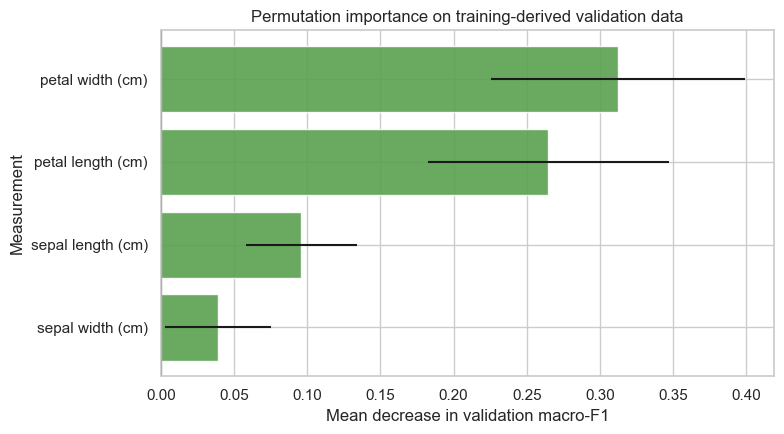

,feature,importance_mean,importance_sd
3,petal width (cm),0.312,0.087
2,petal length (cm),0.265,0.082
0,sepal length (cm),0.096,0.038
1,sepal width (cm),0.039,0.036


In [10]:
importance_result = permutation_importance(
    interpretation_model,
    X_validation,
    y_validation,
    scoring=PRIMARY_SCORING,
    n_repeats=30,
    random_state=INTERPRETATION_RANDOM_STATE,
    n_jobs=1,
)
importance = (
    pd.DataFrame({
        "feature": X.columns,
        "importance_mean": importance_result.importances_mean,
        "importance_sd": importance_result.importances_std,
    })
    .sort_values("importance_mean", ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(
    importance["feature"], importance["importance_mean"],
    xerr=importance["importance_sd"], color="#59A14F", alpha=0.9,
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set(
    title="Permutation importance on training-derived validation data",
    xlabel="Mean decrease in validation macro-F1",
    ylabel="Measurement",
)
plt.tight_layout()
plt.show()

importance.sort_values("importance_mean", ascending=False).round(3)

## 6. One locked evaluation on the untouched test set

Now—and only now—we access the test partition. Macro-F1 is the declared primary metric. A fixed-seed stratified bootstrap gives a descriptive 95% interval for this particular held-out sample; it does not include dataset-shift or model-selection uncertainty.

In [11]:
test_predictions = best_model.predict(X_test)
baseline_predictions = baseline.predict(X_test)
labels = list(iris.target_names)

test_macro_f1 = f1_score(
    y_test, test_predictions, labels=labels, average="macro", zero_division=0
)
baseline_macro_f1 = f1_score(
    y_test, baseline_predictions, labels=labels, average="macro", zero_division=0
)
test_accuracy = accuracy_score(y_test, test_predictions)

rng = np.random.default_rng(BOOTSTRAP_RANDOM_STATE)
y_test_array = y_test.to_numpy()
class_indices = [np.flatnonzero(y_test_array == label) for label in labels]
bootstrap_f1 = []
for _ in range(2_000):
    sampled = np.concatenate([
        rng.choice(indices, size=len(indices), replace=True) for indices in class_indices
    ])
    bootstrap_f1.append(f1_score(
        y_test_array[sampled], test_predictions[sampled],
        labels=labels, average="macro", zero_division=0,
    ))
f1_ci_low, f1_ci_high = np.percentile(bootstrap_f1, [2.5, 97.5])

print(f"LOCKED TEST {PRIMARY_METRIC}: {test_macro_f1:.3f}")
print(f"Descriptive stratified-bootstrap 95% CI: [{f1_ci_low:.3f}, {f1_ci_high:.3f}]")
print(f"Prior-only baseline macro-F1: {baseline_macro_f1:.3f}")
print(f"Secondary test accuracy: {test_accuracy:.3f}")
print("\nClassification report (secondary diagnostics):")
print(classification_report(
    y_test, test_predictions, labels=labels, target_names=labels,
    digits=3, zero_division=0,
))

LOCKED TEST macro-F1: 0.967
Descriptive stratified-bootstrap 95% CI: [0.898, 1.000]
Prior-only baseline macro-F1: 0.167
Secondary test accuracy: 0.967

Classification report (secondary diagnostics):
              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        10
  versicolor      1.000     0.900     0.947        10
   virginica      0.909     1.000     0.952        10

    accuracy                          0.967        30
   macro avg      0.970     0.967     0.967        30
weighted avg      0.970     0.967     0.967        30



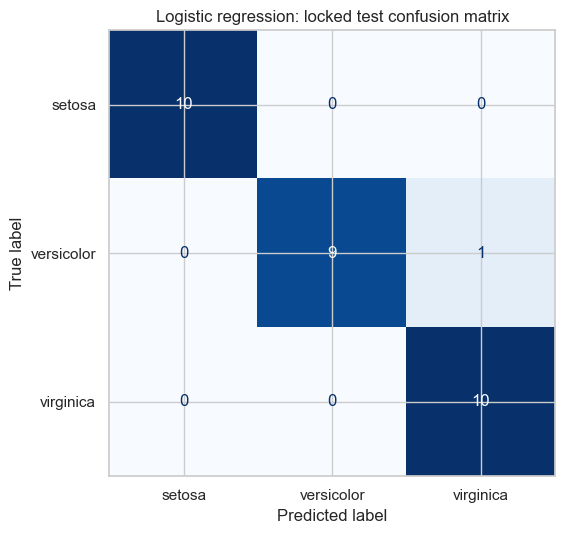

In [12]:
fig, ax = plt.subplots(figsize=(7, 5.5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    labels=list(iris.target_names),
    display_labels=list(iris.target_names),
    cmap="Blues",
    colorbar=False,
    ax=ax,
)
ax.set_title(f"{best_model_name}: locked test confusion matrix")
plt.tight_layout()
plt.show()

## 7. Conclusions and limitations

Use the locked outputs to write the final narrative:

1. Report test macro-F1 and its descriptive bootstrap interval as the primary result.
2. Compare with the prior-only macro-F1 baseline; use accuracy and the confusion matrix as secondary diagnostics.
3. Compare validation permutation importance with the training-only EDA hypothesis.
4. Note that this dataset is tiny, unusually clean, and balanced; the interval does not represent dataset shift or model-selection uncertainty.

**Possible next steps:** nested cross-validation, probability calibration, more diverse flowers, and uncertainty across repeated splits.

In [13]:
top_feature = importance.sort_values("importance_mean", ascending=False).iloc[0]["feature"]
print(f"Selected model: {best_model_name}")
print(f"Locked test macro-F1: {test_macro_f1:.3f} [95% CI {f1_ci_low:.3f}, {f1_ci_high:.3f}]")
print(f"Highest validation macro-F1 permutation importance: {top_feature}")
print("Iris capstone complete: validate -> lock test -> train EDA -> CV -> validation interpretation -> locked test.")

Selected model: Logistic regression
Locked test macro-F1: 0.967 [95% CI 0.898, 1.000]
Highest validation macro-F1 permutation importance: petal width (cm)
Iris capstone complete: validate -> lock test -> train EDA -> CV -> validation interpretation -> locked test.
